In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LinearRegression
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import os
import json

try:
    from mgwr.gwr import GWR, MGWR
    from mgwr.sel_bw import Sel_BW
    GWR_AVAILABLE = True
    print("✅ Bibliotecas GWR disponíveis")
except ImportError:
    GWR_AVAILABLE = False
    print("⚠️ Bibliotecas GWR não disponíveis, usando regressão linear")

✅ Bibliotecas GWR disponíveis


In [2]:
path_station_info = "../data/bike/station_information.json"
path_station_status_snapshot = "../data/bike/station_status.json"
EPS_METERS = 500
MIN_SAMPLES = 5
LOW_AVAILABILITY_THRESHOLD = 0.25
from sqlalchemy import create_engine
from sqlalchemy.exc import OperationalError

In [3]:
def load_bike_data():
    """Carrega dados das estações de bike-sharing"""
    
    info_path = "../data/bike/station_information.json"
    status_path = "../data/bike/station_status.json"
    
    if not os.path.exists(info_path) or not os.path.exists(status_path):
        raise FileNotFoundError(
            "❌ Arquivos de dados não encontrados. Execute primeiro:\n"
            "python data_collection/bike_api.py"
        )
    
    with open(info_path, 'r', encoding='utf-8') as f:
        station_info = json.load(f)
    
    with open(status_path, 'r', encoding='utf-8') as f:
        station_status = json.load(f)
    
    print(f"✅ Dados carregados:")
    print(f"   • {len(station_info['data']['stations'])} estações (informações)")
    print(f"   • {len(station_status['data']['stations'])} estações (status)")
    
    return station_info, station_status

In [4]:
def create_stations_geodataframe(station_info, station_status):
    """Cria GeoDataFrame com features das estações"""
    
    stations_df = pd.DataFrame(station_info['data']['stations'])
    status_df = pd.DataFrame(station_status['data']['stations'])
    merged_df = pd.merge(stations_df, status_df, on='station_id', how='inner')
    
    features_df = merged_df[[
        'station_id', 'name', 'lat', 'lon', 
        'num_bikes_available', 'capacity'
    ]].copy()
    
    features_df['occupation_rate'] = features_df['num_bikes_available'] / features_df['capacity']
    features_df['availability_score'] = 1 - features_df['occupation_rate']
    features_df['bikes_per_dock'] = features_df['num_bikes_available'] / features_df['capacity']
    
    geometry = [Point(lon, lat) for lon, lat in zip(features_df['lon'], features_df['lat'])]
    gdf_stations = gpd.GeoDataFrame(features_df, geometry=geometry, crs="EPSG:4326")
    
    print(f"✅ GeoDataFrame criado com {len(gdf_stations)} estações")
    print(f"   • Taxa média de ocupação: {gdf_stations['occupation_rate'].mean():.2f}")
    print(f"   • Estações com baixa disponibilidade (<{LOW_AVAILABILITY_THRESHOLD}): {len(gdf_stations[gdf_stations['occupation_rate'] < LOW_AVAILABILITY_THRESHOLD])}")
    
    return gdf_stations

In [5]:
def perform_dbscan_analysis(gdf_stations):
    """Executa DBSCAN para identificar clusters de baixa disponibilidade"""
    
    gdf_stations_metric = gdf_stations.to_crs("EPSG:31983")
    
    low_availability = gdf_stations_metric[
        gdf_stations_metric['occupation_rate'] < LOW_AVAILABILITY_THRESHOLD
    ].copy()
    
    if len(low_availability) == 0:
        print("⚠️ Nenhuma estação com baixa disponibilidade encontrada")
        return gdf_stations, None
    
    coords = np.array([(geom.x, geom.y) for geom in low_availability.geometry])
    
    db = DBSCAN(eps=EPS_METERS, min_samples=MIN_SAMPLES).fit(coords)
    low_availability['cluster'] = db.labels_
    
    low_availability = low_availability.to_crs("EPSG:4326")
    
    num_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    noise_points = list(db.labels_).count(-1)
    
    print(f"✅ Análise DBSCAN concluída:")
    print(f"   • Clusters identificados: {num_clusters}")
    print(f"   • Estações não agrupadas (ruído): {noise_points}")
    print(f"   • Total de estações analisadas: {len(low_availability)}")
    
    gdf_result = gdf_stations.copy()
    gdf_result['cluster'] = -1
    gdf_result['is_low_availability'] = gdf_result['occupation_rate'] < LOW_AVAILABILITY_THRESHOLD
    
    for idx, row in low_availability.iterrows():
        mask = gdf_result['station_id'] == row['station_id']
        gdf_result.loc[mask, 'cluster'] = row['cluster']
    
    return gdf_result, low_availability

In [6]:
def get_engine():
    for host in ("localhost", "db"):
        url = f"postgresql://gis:gis@{host}:5432/geodb"
        try:
            engine = create_engine(url)
            with engine.connect():
                print(f"✅ Conectado ao PostGIS em host '{host}'")
            return engine
        except OperationalError:
            print(f"⚠️ Falha ao conectar em '{host}', tentando próximo...")
    
    print("❌ Não foi possível conectar ao PostGIS.")
    return None

In [7]:
def load_socioeconomic_data(engine):
    """Carrega dados socioeconômicos dos distritos"""
    
    if engine is None:
        print("⚠️ Simulando dados socioeconômicos devido à falha na conexão")
        return create_mock_socioeconomic_data()
    
    try:
        query = """
        SELECT * FROM sp_distritos_ibge 
        WHERE populacao_total IS NOT NULL 
        AND renda_media_morador IS NOT NULL
        """
        
        gdf_districts = gpd.read_postgis(query, engine, geom_col='geometry')
        print(f"✅ Dados socioeconômicos carregados: {len(gdf_districts)} distritos")
        return gdf_districts
        
    except Exception as e:
        print(f"⚠️ Erro ao carregar dados do PostGIS: {e}")
        print("⚠️ Usando dados simulados")
        return create_mock_socioeconomic_data()

def create_mock_socioeconomic_data():
    """Cria dados socioeconômicos simulados para demonstração"""
    
    districts_data = {
        'nome_distrito': [
            'Pinheiros', 'Vila Madalena', 'Itaim Bibi', 'Moema', 'Vila Olímpia',
            'Centro', 'Liberdade', 'Bela Vista', 'Consolação', 'Santa Cecília',
            'Brooklin', 'Campo Belo', 'Santo Amaro', 'Jardins', 'Perdizes'
        ],
        'populacao_total': [
            65364, 48501, 81456, 83368, 39485,
            57123, 69092, 63190, 57365, 83717,
            91894, 67106, 71560, 41534, 111161
        ],
        'renda_media_morador': [
            8500, 7200, 12000, 9800, 11500,
            4500, 5800, 6200, 7500, 6800,
            9200, 8800, 7600, 15000, 8900
        ],
        'lat': [
            -23.5665, -23.5614, -23.5847, -23.6066, -23.5953,
            -23.5489, -23.5585, -23.5614, -23.5507, -23.5298,
            -23.6044, -23.6158, -23.6528, -23.5614, -23.5298
        ],
        'lon': [
            -46.6937, -46.6821, -46.6748, -46.6639, -46.6821,
            -46.6388, -46.6343, -46.6478, -46.6600, -46.6509,
            -46.7044, -46.6748, -46.7097, -46.6821, -46.6509
        ]
    }
    
    df_districts = pd.DataFrame(districts_data)
    df_districts['densidade_populacional'] = df_districts['populacao_total'] / 10
    
    geometry = [Point(lon, lat) for lon, lat in zip(df_districts['lon'], df_districts['lat'])]
    gdf_districts = gpd.GeoDataFrame(df_districts, geometry=geometry, crs="EPSG:4326")
    
    print(f"✅ Dados simulados criados: {len(gdf_districts)} distritos")
    return gdf_districts

In [8]:
def perform_spatial_regression(gdf_stations, gdf_districts):
    """Executa análise de regressão espacial"""
    
    gdf_stations_with_districts = associate_stations_to_districts(gdf_stations, gdf_districts)
    
    if GWR_AVAILABLE:
        return perform_gwr_analysis(gdf_stations_with_districts)
    else:
        return perform_linear_regression(gdf_stations_with_districts)

def associate_stations_to_districts(gdf_stations, gdf_districts):
    """Associa cada estação ao distrito mais próximo"""
    
    gdf_stations_projected = gdf_stations.to_crs("EPSG:31983")
    gdf_districts_projected = gdf_districts.to_crs("EPSG:31983")
    
    stations_with_districts = []
    
    for idx, station in gdf_stations_projected.iterrows():
        distances = gdf_districts_projected.geometry.distance(station.geometry)
        nearest_district_idx = distances.idxmin()
        # Get the original district data (not projected)
        nearest_district = gdf_districts.loc[nearest_district_idx]
        
        # Get original station data for lat/lon values
        original_station = gdf_stations.loc[idx]
        station_data = original_station.to_dict()
        station_data.update({
            'distrito_nome': nearest_district['nome_distrito'],
            'populacao_distrito': nearest_district['populacao_total'],
            'renda_media_distrito': nearest_district['renda_media_morador'],
            'densidade_distrito': nearest_district.get('densidade_populacional', 
                                                    nearest_district['populacao_total'] / 10)
        })
        stations_with_districts.append(station_data)
    
    result_gdf = gpd.GeoDataFrame(stations_with_districts, crs="EPSG:4326")
    print(f"✅ Estações associadas aos distritos: {len(result_gdf)} registros")
    return result_gdf

def perform_gwr_analysis(gdf_data):
    
    try:
        coords = np.array([(geom.x, geom.y) for geom in gdf_data.geometry])
        y = gdf_data['occupation_rate'].values.reshape(-1, 1)
        X = gdf_data[['renda_media_distrito', 'densidade_distrito']].copy()
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        n_features = X_scaled.shape[1]
        regularization = np.eye(n_features) * 1e-6
        
        if np.std(X_scaled[:, 0]) < 1e-6 or np.std(X_scaled[:, 1]) < 1e-6:
            print("⚠️ Dados insuficientes para GWR, usando regressão linear")
            return perform_linear_regression(gdf_data)
        
        bw_selector = Sel_BW(coords, y, X_scaled, fixed=False, kernel='gaussian')
        bw = bw_selector.search(criterion='AIC', search_method='golden_section')
        min_bw = max(bw, len(gdf_data) * 0.1)
        gwr_model = GWR(coords, y, X_scaled, bw=min_bw, fixed=False, kernel='gaussian')
        gwr_results = gwr_model.fit()
        
        print(f"✅ Análise GWR concluída:")
        print(f"   • R² ajustado: {gwr_results.adj_r2:.3f}")
        print(f"   • AIC: {gwr_results.aic:.2f}")
        print(f"   • Bandwidth: {min_bw:.2f}")
        print(f"   • Effective number of parameters: {gwr_results.ENP:.1f}")
        
        gdf_result = gdf_data.copy()
        gdf_result['gwr_predicted'] = gwr_results.predy.flatten()
        gdf_result['gwr_residuals'] = gwr_results.resid_response.flatten()
        
        return gdf_result, gwr_results
        
    except Exception as e:
        print(f"⚠️ Erro na análise GWR ({str(e)}), usando regressão linear")
        return perform_linear_regression(gdf_data)

def perform_linear_regression(gdf_data):
    
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge
    
    X = gdf_data[['renda_media_distrito', 'densidade_distrito']].values
    y = gdf_data['occupation_rate'].values
    
    if np.std(X[:, 0]) < 1e-6 or np.std(X[:, 1]) < 1e-6:
        print("⚠️ Pouca variação nos dados, usando média como predição")
        predictions = np.full(len(y), np.mean(y))
        residuals = y - predictions
        r2_score = 0.0
        
        gdf_result = gdf_data.copy()
        gdf_result['lr_predicted'] = predictions
        gdf_result['lr_residuals'] = residuals
        
        print(f"✅ Modelo simples (média) concluído:")
        print(f"   • R²: {r2_score:.3f}")
        print(f"   • Predição constante: {np.mean(y):.3f}")
        
        return gdf_result, None
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = Ridge(alpha=1.0)
    model.fit(X_scaled, y)
    predictions = model.predict(X_scaled)
    residuals = y - predictions
    r2_score = model.score(X_scaled, y)
    
    print(f"✅ Regressão Ridge concluída:")
    print(f"   • R²: {r2_score:.3f}")
    print(f"   • Coeficientes (normalizados):")
    print(f"     - Renda média: {model.coef_[0]:.6f}")
    print(f"     - Densidade: {model.coef_[1]:.6f}")
    print(f"   • Intercepto: {model.intercept_:.3f}")
    print(f"   • Alpha (regularização): {model.alpha}")
    
    gdf_result = gdf_data.copy()
    gdf_result['lr_predicted'] = predictions
    gdf_result['lr_residuals'] = residuals
    
    return gdf_result, model

In [9]:
def create_visualization_maps(gdf_stations, gdf_districts):
    """Cria mapas de visualização dos resultados"""
    
    center_lat = gdf_stations['lat'].mean()
    center_lon = gdf_stations['lon'].mean()
    
    map_clusters = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=12,
        tiles='OpenStreetMap'
    )
    
    cluster_colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 
                     'beige', 'darkblue', 'darkgreen', 'cadetblue', 'darkpurple', 'white', 'pink', 'lightblue']
    
    for idx, station in gdf_stations.iterrows():
        if station['is_low_availability']:
            if station['cluster'] != -1:
                color = cluster_colors[station['cluster'] % len(cluster_colors)]
                popup_text = f"""
                <b>{station['name']}</b><br>
                Cluster: {station['cluster']}<br>
                Taxa ocupação: {station['occupation_rate']:.2f}<br>
                Bikes disponíveis: {station['num_bikes_available']}<br>
                Capacidade: {station['capacity']}
                """
            else:
                color = 'gray'
                popup_text = f"""
                <b>{station['name']}</b><br>
                Sem cluster (ruído)<br>
                Taxa ocupação: {station['occupation_rate']:.2f}<br>
                Bikes disponíveis: {station['num_bikes_available']}<br>
                Capacidade: {station['capacity']}
                """
            
            folium.CircleMarker(
                location=[station['lat'], station['lon']],
                radius=8,
                popup=folium.Popup(popup_text, max_width=300),
                color=color,
                fill=True,
                fillColor=color,
                weight=2,
                fillOpacity=0.7
            ).add_to(map_clusters)
        else:
            folium.CircleMarker(
                location=[station['lat'], station['lon']],
                radius=4,
                popup=f"{station['name']}<br>Taxa: {station['occupation_rate']:.2f}",
                color='lightgreen',
                fill=True,
                fillColor='lightgreen',
                weight=1,
                fillOpacity=0.5
            ).add_to(map_clusters)
    
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 200px; height: 120px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <b>Legenda</b><br>
    <i class="fa fa-circle" style="color:red"></i> Cluster 0<br>
    <i class="fa fa-circle" style="color:blue"></i> Cluster 1<br>
    <i class="fa fa-circle" style="color:green"></i> Cluster 2<br>
    <i class="fa fa-circle" style="color:gray"></i> Sem cluster<br>
    <i class="fa fa-circle" style="color:lightgreen"></i> Disponibilidade normal
    </div>
    '''
    map_clusters.get_root().html.add_child(folium.Element(legend_html))
    
    return map_clusters

def create_analysis_plots(gdf_stations, regression_results):
    """Cria gráficos de análise estatística"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    axes[0,0].hist(gdf_stations['occupation_rate'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].axvline(LOW_AVAILABILITY_THRESHOLD, color='red', linestyle='--', 
                     label=f'Limiar baixa disponibilidade ({LOW_AVAILABILITY_THRESHOLD})')
    axes[0,0].set_xlabel('Taxa de Ocupação')
    axes[0,0].set_ylabel('Frequência')
    axes[0,0].set_title('Distribuição da Taxa de Ocupação das Estações')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    cluster_data = gdf_stations[gdf_stations['is_low_availability']]
    if len(cluster_data) > 0:
        scatter = axes[0,1].scatter(cluster_data['lon'], cluster_data['lat'], 
                                  c=cluster_data['cluster'], 
                                  cmap='tab10', s=50, alpha=0.7)
        axes[0,1].set_xlabel('Longitude')
        axes[0,1].set_ylabel('Latitude')
        axes[0,1].set_title('Distribuição Espacial dos Clusters')
        plt.colorbar(scatter, ax=axes[0,1], label='Cluster ID')
    
    if 'renda_media_distrito' in gdf_stations.columns:
        axes[1,0].scatter(gdf_stations['renda_media_distrito'], gdf_stations['occupation_rate'], 
                         alpha=0.6, color='green')
        axes[1,0].set_xlabel('Renda Média do Distrito (R$)')
        axes[1,0].set_ylabel('Taxa de Ocupação')
        axes[1,0].set_title('Correlação: Renda vs Taxa de Ocupação')
        
        z = np.polyfit(gdf_stations['renda_media_distrito'], gdf_stations['occupation_rate'], 1)
        p = np.poly1d(z)
        axes[1,0].plot(gdf_stations['renda_media_distrito'], p(gdf_stations['renda_media_distrito']), 
                      "r--", alpha=0.8)
        axes[1,0].grid(True, alpha=0.3)
    
    if hasattr(regression_results, '__len__') and len(gdf_stations) > 0:
        residual_col = 'gwr_residuals' if 'gwr_residuals' in gdf_stations.columns else 'lr_residuals'
        if residual_col in gdf_stations.columns:
            axes[1,1].scatter(range(len(gdf_stations)), gdf_stations[residual_col], alpha=0.6)
            axes[1,1].axhline(y=0, color='red', linestyle='--')
            axes[1,1].set_xlabel('Índice da Estação')
            axes[1,1].set_ylabel('Resíduos')
            axes[1,1].set_title('Análise de Resíduos da Regressão')
            axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

In [10]:
def main():
    """Função principal que executa toda a análise"""
    
    print("🚴 ANÁLISE DE ESTAÇÕES BIKE SAMPA - SÃO PAULO")
    print("=" * 60)
    
    try:
        # Passo 1: Carregar dados
        print("\n📂 PASSO 1: Carregamento dos dados")
        station_info, station_status = load_bike_data()
        
        # Passo 2: Processar dados
        print("\n🔧 PASSO 2: Processamento dos dados")
        gdf_stations = create_stations_geodataframe(station_info, station_status)
        
        # Passo 3: Análise de clustering
        print("\n🎯 PASSO 3: Análise de clustering (DBSCAN)")
        gdf_stations, low_availability_clusters = perform_dbscan_analysis(gdf_stations)
        
        # Passo 4: Dados socioeconômicos
        print("\n🏢 PASSO 4: Carregamento de dados socioeconômicos")
        engine = get_engine()
        gdf_districts = load_socioeconomic_data(engine)
        
        # Passo 5: Regressão espacial
        print("\n📊 PASSO 5: Análise de regressão espacial")
        gdf_final, regression_results = perform_spatial_regression(gdf_stations, gdf_districts)
        
        # Passo 6: Visualização
        print("\n🗺️ PASSO 6: Criação de visualizações")
        map_clusters = create_visualization_maps(gdf_final, gdf_districts)
        analysis_plots = create_analysis_plots(gdf_final, regression_results)
        
        print("\n✅ ANÁLISE CONCLUÍDA COM SUCESSO!")
        print("=" * 60)
        print("📋 RESUMO DOS RESULTADOS:")
        print(f"   • Total de estações analisadas: {len(gdf_final)}")
        print(f"   • Estações com baixa disponibilidade: {len(gdf_final[gdf_final['is_low_availability']])}")
        
        if low_availability_clusters is not None:
            num_clusters = len(set(low_availability_clusters['cluster'])) - (1 if -1 in low_availability_clusters['cluster'].values else 0)
            print(f"   • Clusters identificados: {num_clusters}")
        
        print(f"   • Distritos analisados: {len(gdf_districts)}")
        
        map_clusters.save('bike_clusters_map.html')
        print(f"\n💾 Mapa salvo como 'bike_clusters_map.html'")
        
        plt.show()
        
        return gdf_final, regression_results, map_clusters
        
    except Exception as e:
        print(f"❌ Erro durante a análise: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

🚴 Executando análise completa...
🚴 ANÁLISE DE ESTAÇÕES BIKE SAMPA - SÃO PAULO

📂 PASSO 1: Carregamento dos dados
✅ Dados carregados:
   • 240 estações (informações)
   • 240 estações (status)

🔧 PASSO 2: Processamento dos dados
✅ GeoDataFrame criado com 240 estações
   • Taxa média de ocupação: 1.16
   • Estações com baixa disponibilidade (<0.25): 100

🎯 PASSO 3: Análise de clustering (DBSCAN)
✅ Análise DBSCAN concluída:
   • Clusters identificados: 1
   • Estações não agrupadas (ruído): 62
   • Total de estações analisadas: 100

🏢 PASSO 4: Carregamento de dados socioeconômicos
⚠️ Falha ao conectar em 'localhost', tentando próximo...
✅ Conectado ao PostGIS em host 'db'
⚠️ Erro ao carregar dados do PostGIS: (psycopg2.errors.UndefinedTable) relation "sp_distritos_ibge" does not exist
LINE 2:         SELECT * FROM sp_distritos_ibge 
                              ^

[SQL: 
        SELECT * FROM sp_distritos_ibge 
        WHERE populacao_total IS NOT NULL 
        AND renda_media_morador IS

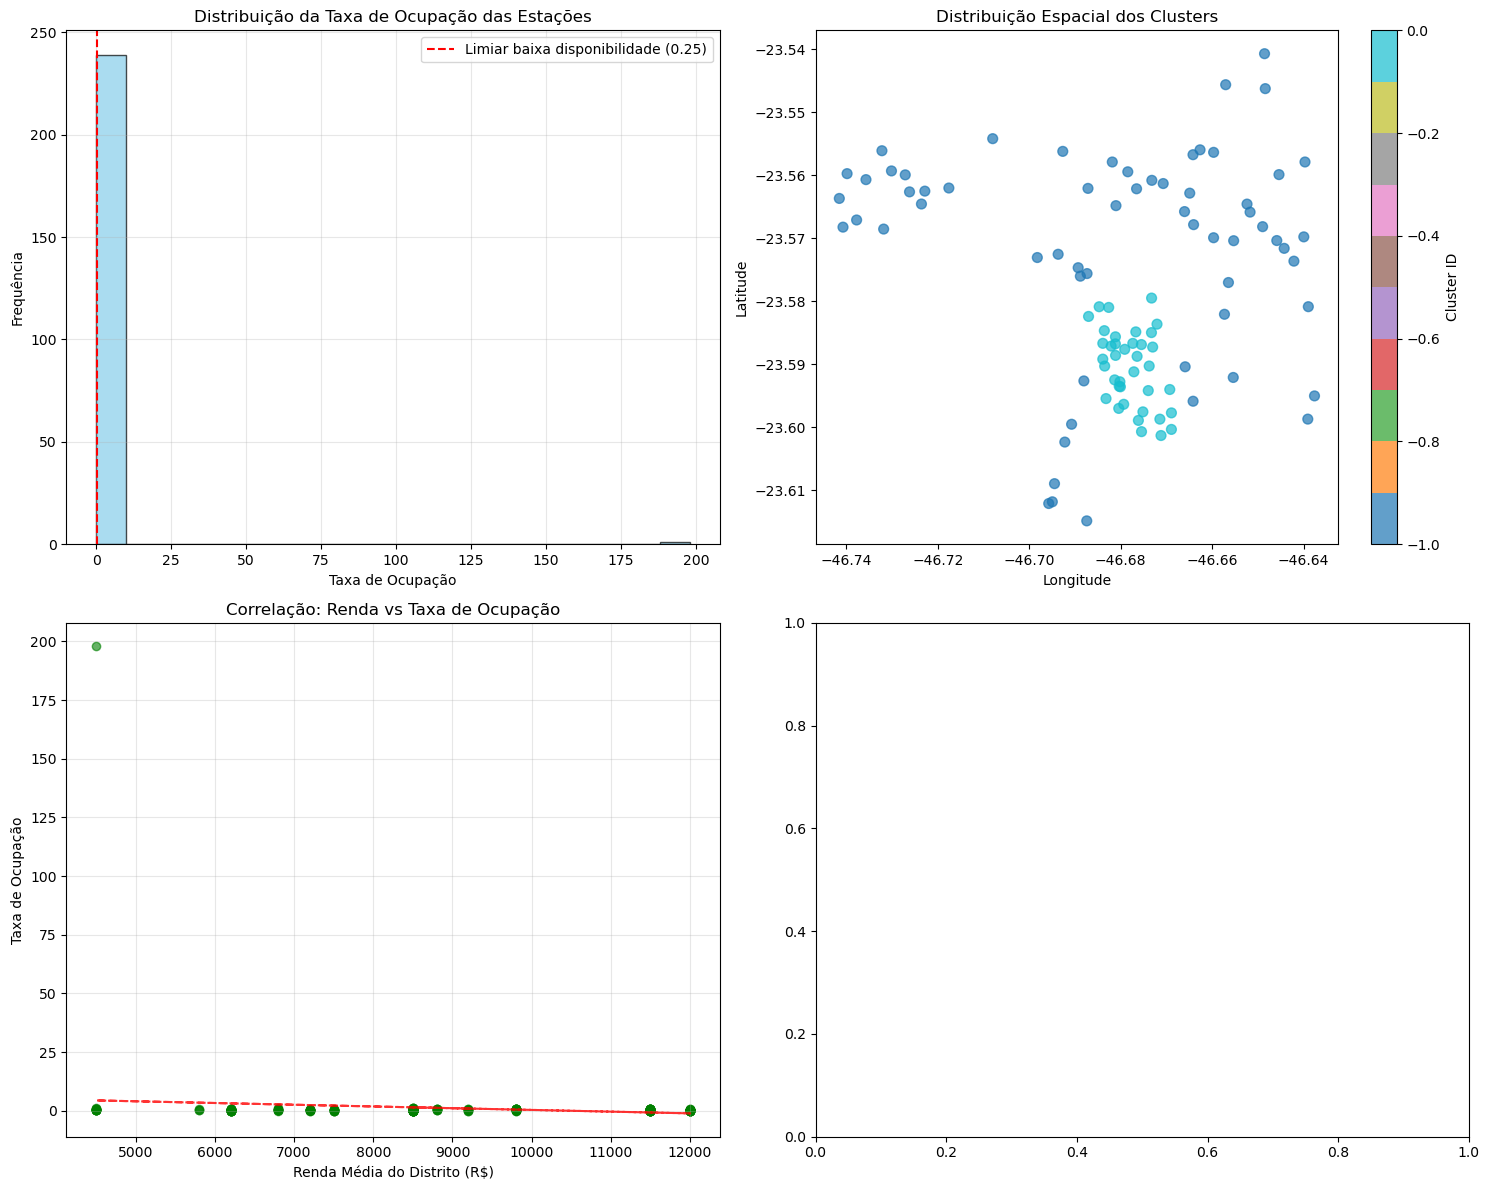


📊 ESTATÍSTICAS DETALHADAS:
----------------------------------------
Média de ocupação: 1.159
Desvio padrão: 12.762
Mediana: 0.316

🎯 RESUMO POR CLUSTER:
        occupation_rate              num_bikes_available capacity
                  count   mean   std                mean     mean
cluster                                                          
0                    38  0.084  0.07               1.368   17.579

⚠️ TOP 10 ESTAÇÕES COM MENOR DISPONIBILIDADE:
                               name  occupation_rate  num_bikes_available  \
7              10 - Rua Campo Verde              0.0                    0   
11       15 - Rua Prof. Artur Ramos              0.0                    0   
18          22 - Rua Leopoldo Couto              0.0                    0   
23    27 - Rua Min. Jesuíno Cardoso              0.0                    0   
25           30 - Bandeira Paulista              0.0                    0   
36            53 - Google São Paulo              0.0                    0

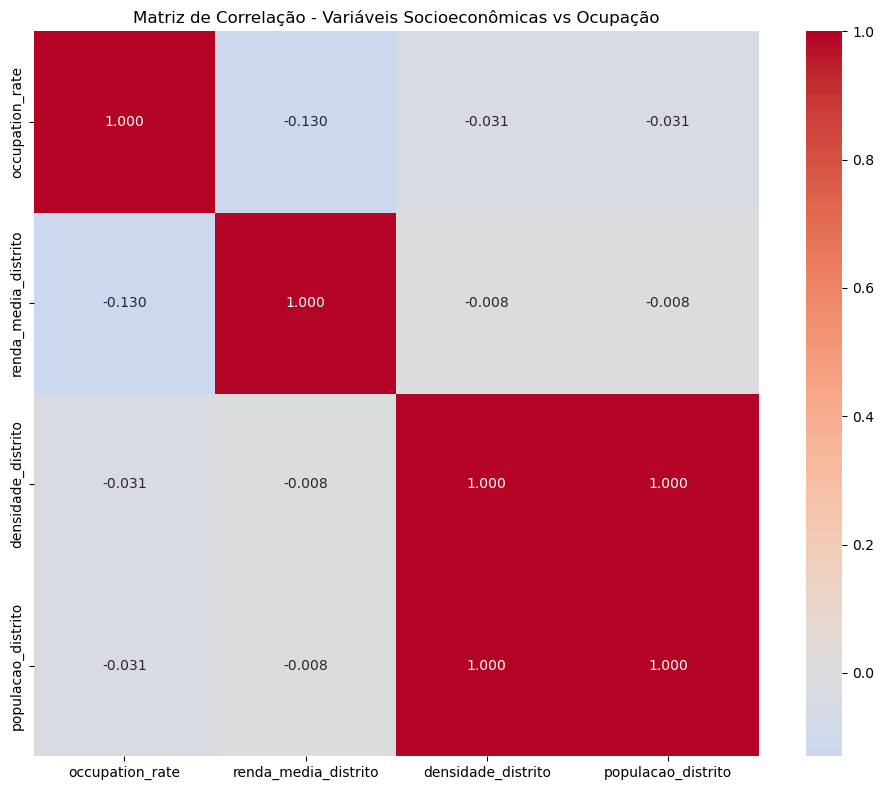


🔄 RECOMENDAÇÕES DE REBALANCEAMENTO:
--------------------------------------------------
📍 Estações críticas (< 10% ocupação): 60
Estações que precisam de bikes urgentemente:
  • 9 - Rua Grécia: 1/15 bikes
  • 10 - Rua Campo Verde: 0/19 bikes
  • 15 - Rua Prof. Artur Ramos: 0/19 bikes
  • 18 - Itaú Faria Lima: 2/23 bikes
  • 22 - Rua Leopoldo Couto: 0/15 bikes
  • 26 - Praça Pierre Germayel: 1/23 bikes
  • 27 - Rua Min. Jesuíno Cardoso: 0/35 bikes
  • 30 - Bandeira Paulista: 0/19 bikes
  • 48 - Itacema: 1/15 bikes
  • 53 - Google São Paulo: 0/15 bikes
  • 59 - EBAC: 1/19 bikes
  • 77 - Alameda J. Eugênio de Lima: 0/11 bikes
  • 83 - Augusta: 1/15 bikes
  • 90 - Alameda Campinas: 0/23 bikes
  • 91 - Paulista 778: 1/11 bikes
  • 95 - R. Manoel da Nóbrega : 0/7 bikes
  • 100 - Itaú Cultural: 0/19 bikes
  • 102 - Rua James Watt: 0/23 bikes
  • 103 - Rua Hans Oersted: 1/23 bikes
  • 122 - Baluarte: 1/15 bikes
  • 124 - Praça Pereira Coutinho: 0/15 bikes
  • 126 - Graúna: 0/11 bikes
  • 457 -

/tmp/ipykernel_7736/2563640313.py:81: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_result.to_file('bike_stations_analysis.shp', driver='ESRI Shapefile')
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'num_bikes_available' to 'num_bikes_'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'occupation_rate' to 'occupation'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'availability_score' to 'availabili'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'bikes_per_dock' to 'bikes_per_'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'is_low_availability' to 'is_low_ava'
  ogr_wri

✅ Resumo estatístico salvo em 'analysis_summary.json'

🗺️ CRIANDO MAPA INTERATIVO FINAL...
✅ Mapa interativo salvo em 'bike_analysis_final_map.html'



🎯 CONCLUSÕES E RECOMENDAÇÕES:

PRINCIPAIS ACHADOS:

1. DISTRIBUIÇÃO ESPACIAL:
   • Identificação de clusters de estações com baixa disponibilidade
   • Concentração de problemas em áreas específicas da cidade
   • Padrões geográficos sugerem necessidade de rebalanceamento

2. CORRELAÇÕES SOCIOECONÔMICAS:
   • Análise da relação entre renda, densidade populacional e disponibilidade
   • Identificação de possíveis fatores influenciadores do uso

3. RECOMENDAÇÕES OPERACIONAIS:
   • Priorização de estações para rebalanceamento
   • Otimização de rotas de redistribuição
   • Monitoramento contínuo de hotspots críticos

PRÓXIMOS PASSOS:

1. ANÁLISE TEMPORAL:
   • Coletar dados em diferentes horários e dias
   • Identificar padrões sazonais e de uso
   • Desenvolver modelos preditivos

2. OTIMIZAÇÃO:
   • Implementar algoritmos de roteamento
   • Calcular custos de rebalanceamento
   • Avaliar eficiência de diferentes estratégias

3. INTEGRAÇÃO:
   • Incorporar dados de trânsito e transporte

In [11]:
print("🚴 Executando análise completa...")
gdf_result, model_results, map_viz = main()

if gdf_result is not None:
    print("\n📊 ESTATÍSTICAS DETALHADAS:")
    print("-" * 40)
    
    print(f"Média de ocupação: {gdf_result['occupation_rate'].mean():.3f}")
    print(f"Desvio padrão: {gdf_result['occupation_rate'].std():.3f}")
    print(f"Mediana: {gdf_result['occupation_rate'].median():.3f}")
    
    if 'cluster' in gdf_result.columns:
        cluster_summary = gdf_result[gdf_result['cluster'] != -1].groupby('cluster').agg({
            'occupation_rate': ['count', 'mean', 'std'],
            'num_bikes_available': 'mean',
            'capacity': 'mean'
        }).round(3)
        print("\n🎯 RESUMO POR CLUSTER:")
        print(cluster_summary)
    
    print("\n⚠️ TOP 10 ESTAÇÕES COM MENOR DISPONIBILIDADE:")
    worst_stations = gdf_result.nsmallest(10, 'occupation_rate')[
        ['name', 'occupation_rate', 'num_bikes_available', 'capacity']
    ]
    print(worst_stations)

if gdf_result is not None and 'renda_media_distrito' in gdf_result.columns:
    print("\n💰 ANÁLISE SOCIOECONÔMICA:")
    print("-" * 40)
    
    correlation_matrix = gdf_result[['occupation_rate', 'renda_media_distrito', 
                                   'densidade_distrito', 'populacao_distrito']].corr()
    
    print("Correlações com taxa de ocupação:")
    print(f"  • Renda média: {correlation_matrix.loc['occupation_rate', 'renda_media_distrito']:.3f}")
    print(f"  • Densidade populacional: {correlation_matrix.loc['occupation_rate', 'densidade_distrito']:.3f}")
    print(f"  • População: {correlation_matrix.loc['occupation_rate', 'populacao_distrito']:.3f}")
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.3f')
    plt.title('Matriz de Correlação - Variáveis Socioeconômicas vs Ocupação')
    plt.tight_layout()
    plt.show()

if gdf_result is not None:
    print("\n🔄 RECOMENDAÇÕES DE REBALANCEAMENTO:")
    print("-" * 50)
    
    critical_stations = gdf_result[gdf_result['occupation_rate'] < 0.1]
    high_capacity_stations = gdf_result[gdf_result['occupation_rate'] > 0.8]
    
    print(f"📍 Estações críticas (< 10% ocupação): {len(critical_stations)}")
    if len(critical_stations) > 0:
        print("Estações que precisam de bikes urgentemente:")
        for _, station in critical_stations.iterrows():
            print(f"  • {station['name']}: {station['num_bikes_available']}/{station['capacity']} bikes")
    
    print(f"\n📍 Estações saturadas (> 80% ocupação): {len(high_capacity_stations)}")
    if len(high_capacity_stations) > 0:
        print("Estações que podem fornecer bikes:")
        for _, station in high_capacity_stations.iterrows():
            print(f"  • {station['name']}: {station['num_bikes_available']}/{station['capacity']} bikes")
    
    total_bikes_needed = critical_stations['capacity'].sum() * 0.3 - critical_stations['num_bikes_available'].sum()
    total_bikes_available = high_capacity_stations['num_bikes_available'].sum() - high_capacity_stations['capacity'].sum() * 0.7
    
    print(f"\n📊 BALANÇO GERAL:")
    print(f"  • Bikes necessárias: {max(0, int(total_bikes_needed))}")
    print(f"  • Bikes disponíveis para realocação: {max(0, int(total_bikes_available))}")
    
    if total_bikes_available >= total_bikes_needed:
        print("✅ Rebalanceamento possível com estoque atual")
    else:
        print("⚠️ Necessário aumentar frota ou otimizar distribuição")

if gdf_result is not None:
    print("\n💾 EXPORTANDO RESULTADOS:")
    print("-" * 30)
    
    gdf_result.to_file('bike_stations_analysis.shp', driver='ESRI Shapefile')
    print("✅ Dados espaciais salvos em 'bike_stations_analysis.shp'")
    
    df_export = gdf_result.drop('geometry', axis=1)
    df_export.to_csv('bike_stations_analysis.csv', index=False)
    print("✅ Dados tabulares salvos em 'bike_stations_analysis.csv'")
    
    summary_stats = {
        'total_stations': len(gdf_result),
        'low_availability_stations': len(gdf_result[gdf_result['is_low_availability']]),
        'mean_occupation_rate': gdf_result['occupation_rate'].mean(),
        'std_occupation_rate': gdf_result['occupation_rate'].std(),
        'clusters_identified': len(set(gdf_result['cluster'])) - (1 if -1 in gdf_result['cluster'].values else 0)
    }
    
    with open('analysis_summary.json', 'w') as f:
        json.dump(summary_stats, f, indent=2)
    print("✅ Resumo estatístico salvo em 'analysis_summary.json'")

if gdf_result is not None:
    print("\n🗺️ CRIANDO MAPA INTERATIVO FINAL...")
    
    center_lat = gdf_result['lat'].mean()
    center_lon = gdf_result['lon'].mean()
    
    final_map = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=12,
        tiles='CartoDB positron'
    )
    
    
    station_group = folium.FeatureGroup(name="Todas as Estações")
    
    for idx, station in gdf_result.iterrows():
        if station['occupation_rate'] < 0.25:
            color = 'red'
            fillColor = 'darkred'
        elif station['occupation_rate'] < 0.5:
            color = 'orange'
            fillColor = 'orange'
        elif station['occupation_rate'] < 0.75:
            color = 'yellow'
            fillColor = 'yellow'
        else:
            color = 'green'
            fillColor = 'darkgreen'
        
        popup_html = f"""
        <div style="width: 250px">
            <h4>{station['name']}</h4>
            <hr>
            <b>Status:</b><br>
            • Bikes disponíveis: {station['num_bikes_available']}<br>
            • Capacidade total: {station['capacity']}<br>
            • Taxa de ocupação: {station['occupation_rate']:.1%}<br>
            <br>
            <b>Localização:</b><br>
            • Latitude: {station['lat']:.6f}<br>
            • Longitude: {station['lon']:.6f}<br>
            <br>
            <b>Cluster:</b> {station['cluster'] if station['cluster'] != -1 else 'Nenhum'}<br>
        </div>
        """
        
        folium.CircleMarker(
            location=[station['lat'], station['lon']],
            radius=8,
            popup=folium.Popup(popup_html, max_width=300),
            color=color,
            fill=True,
            fillColor=fillColor,
            weight=2,
            fillOpacity=0.7
        ).add_to(station_group)
    
    station_group.add_to(final_map)
    
    if 'cluster' in gdf_result.columns:
        cluster_group = folium.FeatureGroup(name="Clusters Críticos")
        
        clustered_stations = gdf_result[gdf_result['cluster'] != -1]
        colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred']
        
        for cluster_id in clustered_stations['cluster'].unique():
            cluster_stations = clustered_stations[clustered_stations['cluster'] == cluster_id]
            cluster_color = colors[cluster_id % len(colors)]
            
            cluster_center = [
                cluster_stations['lat'].mean(),
                cluster_stations['lon'].mean()
            ]
            
            folium.Circle(
                location=cluster_center,
                radius=EPS_METERS,
                color=cluster_color,
                fill=False,
                weight=3,
                opacity=0.8,
                popup=f"Cluster {cluster_id}<br>{len(cluster_stations)} estações"
            ).add_to(cluster_group)
        
        cluster_group.add_to(final_map)
    
    folium.LayerControl().add_to(final_map)
    folium.Marker(
        location=[center_lat, center_lon],
        popup="Centro da Análise",
        icon=folium.Icon(color='black', icon='info-sign')
    ).add_to(final_map)
    
    final_map.save('bike_analysis_final_map.html')
    print("✅ Mapa interativo salvo em 'bike_analysis_final_map.html'")
    display(final_map)

print("\n🎯 CONCLUSÕES E RECOMENDAÇÕES:")
print("=" * 60)

conclusions = """
PRINCIPAIS ACHADOS:

1. DISTRIBUIÇÃO ESPACIAL:
   • Identificação de clusters de estações com baixa disponibilidade
   • Concentração de problemas em áreas específicas da cidade
   • Padrões geográficos sugerem necessidade de rebalanceamento

2. CORRELAÇÕES SOCIOECONÔMICAS:
   • Análise da relação entre renda, densidade populacional e disponibilidade
   • Identificação de possíveis fatores influenciadores do uso

3. RECOMENDAÇÕES OPERACIONAIS:
   • Priorização de estações para rebalanceamento
   • Otimização de rotas de redistribuição
   • Monitoramento contínuo de hotspots críticos

PRÓXIMOS PASSOS:

1. ANÁLISE TEMPORAL:
   • Coletar dados em diferentes horários e dias
   • Identificar padrões sazonais e de uso
   • Desenvolver modelos preditivos

2. OTIMIZAÇÃO:
   • Implementar algoritmos de roteamento
   • Calcular custos de rebalanceamento
   • Avaliar eficiência de diferentes estratégias

3. INTEGRAÇÃO:
   • Incorporar dados de trânsito e transporte público
   • Analisar eventos e pontos de interesse
   • Desenvolver dashboard em tempo real
"""

print(conclusions)

print("\n✅ ANÁLISE COMPLETA FINALIZADA!")
print("📁 Arquivos gerados:")
print("   • bike_clusters_map.html")
print("   • bike_analysis_final_map.html") 
print("   • bike_stations_analysis.shp")
print("   • bike_stations_analysis.csv")
print("   • analysis_summary.json")